In [54]:
import numpy as np
w = np.array([2, 1, 5, 3])
x = np.array([2, 8, 3, 7, 1, 2, 0, 4, 5])
# w_r = w[::-1]
w_r = np.flip(w)
print(w_r)

[3 5 1 2]


In [55]:
for i in range(6):
    print(np.dot(x[i:i+4], w_r))

63
48
49
28
21
20


In [56]:
from scipy.signal import convolve
convolve(x, w, mode='valid')	# 합성곱

array([63, 48, 49, 28, 21, 20])

In [57]:
from scipy.signal import correlate
correlate(x, w, mode='valid')

array([48, 57, 24, 25, 16, 39])

In [58]:
correlate(x, w, mode='full')	# zero padding (연산 참여도 바꿈)

array([ 6, 34, 51, 48, 57, 24, 25, 16, 39, 29, 13, 10])

In [59]:
correlate(x, w, mode='same')	# same padding (출력 배열 길이 = 원본 배열 길이)

array([34, 51, 48, 57, 24, 25, 16, 39, 29])

In [60]:
from scipy.signal import correlate2d
x = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
w = np.array([[2, 0], [0, 0]])
correlate2d(x, w, mode='valid')

array([[ 2,  4],
       [ 8, 10]])

In [61]:
correlate2d(x, w, mode='same')

array([[ 2,  4,  6],
       [ 8, 10, 12],
       [14, 16, 18]])

In [62]:
import tensorflow as tf
x_4d = x.astype(float).reshape(1, 3, 3, 1)
w_4d = w.reshape(2, 2, 1, 1)

In [63]:
c_out = tf.nn.conv2d(x_4d, w_4d, strides=1, padding='SAME')
c_out.numpy().reshape(3, 3)

array([[ 2.,  4.,  6.],
       [ 8., 10., 12.],
       [14., 16., 18.]])

In [64]:
import torch
import torch.nn as nn

# KEY DIFFERENCE — tensor dimension ordering:
#   TensorFlow : NHWC → (batch, height, width, channels)  → reshape(1, 3, 3, 1)
#   PyTorch    : NCHW → (batch, channels, height, width)  → reshape(1, 1, 3, 3)
x_4d_pt = torch.tensor(x).float().reshape(1, 1, 3, 3)

# nn.Conv2d is the high-level layer API — equivalent to tf.keras.layers.Conv2D
# Unlike tf.nn.conv2d (low-level), it owns its weights internally as nn.Parameter
# in_channels=1, out_channels=1, kernel_size=2 matches the 2×2 kernel w used above
conv_layer = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=2, padding='same', bias=False)

# Manually assign w to match the TF example (normally the layer initialises weights randomly)
# KEY DIFFERENCE — weight shape ordering:
#   TensorFlow : (height, width, in_channels, out_channels) → reshape(2, 2, 1, 1)
#   PyTorch    : (out_channels, in_channels, height, width) → reshape(1, 1, 2, 2)
conv_layer.weight = nn.Parameter(torch.tensor(w).float().reshape(1, 1, 2, 2))

c_out_pt = conv_layer(x_4d_pt)

# .detach() drops gradient tracking before reshaping — TF tensors don't require this step
c_out_pt.detach().reshape(3, 3)

tensor([[ 2.,  4.,  6.],
        [ 8., 10., 12.],
        [14., 16., 18.]])

In [65]:
# 풀링 연산
x = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12], [13, 14, 15, 16]])
# B, H, W, C
x = x.reshape(1, 4, 4, 1)

In [66]:
p_out = tf.nn.max_pool2d(x, ksize=2, strides=2, padding='VALID')
print(p_out)
p_out.numpy().reshape(2, 2)

tf.Tensor(
[[[[ 6.]
   [ 8.]]

  [[14.]
   [16.]]]], shape=(1, 2, 2, 1), dtype=float32)


array([[ 6.,  8.],
       [14., 16.]], dtype=float32)

In [67]:
x_t = torch.tensor(x)
# B, C, H, W
x_t = x_t.reshape(1, 1, 4, 4)
p_out_t = torch.nn.functional.max_pool2d(x_t, kernel_size=2, stride=2)
p_out_t.numpy().reshape(2, 2)

array([[ 6,  8],
       [14, 16]])

In [68]:
def relu(x):
    return np.maximum(x, 0)

x = np.array([-1, 2, -3, 4, -5])
relu(x)

array([0, 2, 0, 4, 0])

In [69]:
# tensorflow
r_out = tf.nn.relu(x)
print(r_out.numpy())

# torch
x_t = torch.tensor(x)
torch_relu = torch.nn.ReLU()
r_out_t = torch_relu(x_t)
print(r_out_t.numpy())

[0 2 0 4 0]
[0 2 0 4 0]


In [70]:
# textbook Tensorflow version
import tensorflow as tf

class ConvolutionNetwork_tf:
    
    def __init__(self, n_kernels=10, units=10, batch_size=32, learning_rate=0.1):
        self.n_kernels = n_kernels  # 합성곱의 커널 개수
        self.kernel_size = 3        # 커널 크기
        self.optimizer = None       # 옵티마이저
        self.conv_w = None          # 합성곱 층의 가중치
        self.conv_b = None          # 합성곱 층의 절편
        self.units = units          # 은닉층의 뉴런 개수
        self.batch_size = batch_size  # 배치 크기
        self.w1 = None              # 은닉층의 가중치
        self.b1 = None              # 은닉층의 절편
        self.w2 = None              # 출력층의 가중치
        self.b2 = None              # 출력층의 절편
        self.a1 = None              # 은닉층의 활성화 출력
        self.losses = []            # 훈련 손실
        self.val_losses = []        # 검증 손실
        self.lr = learning_rate     # 학습률

    def forpass(self, x):
        # 3x3 합성곱 연산을 수행합니다.
        c_out = tf.nn.conv2d(x, self.conv_w, strides=1, padding='SAME') + self.conv_b
        # 렐루 활성화 함수를 적용합니다.
        r_out = tf.nn.relu(c_out)
        # 2x2 최대 풀링을 적용합니다.
        p_out = tf.nn.max_pool2d(r_out, ksize=2, strides=2, padding='VALID')
        # 첫 번째 배치 차원을 제외하고 출력을 일렬로 펼칩니다.
        f_out = tf.reshape(p_out, [x.shape[0], -1])
        z1 = tf.matmul(f_out, self.w1) + self.b1     # 첫 번째 층의 선형 식을 계산합니다
        a1 = tf.nn.relu(z1)                          # 활성화 함수를 적용합니다
        z2 = tf.matmul(a1, self.w2) + self.b2        # 두 번째 층의 선형 식을 계산합니다.
        return z2
    
    def init_weights(self, input_shape, n_classes):
        g = tf.initializers.glorot_uniform()
        self.conv_w = tf.Variable(g((3, 3, 1, self.n_kernels)))
        self.conv_b = tf.Variable(np.zeros(self.n_kernels), dtype=float)
        n_features = 14 * 14 * self.n_kernels
        self.w1 = tf.Variable(g((n_features, self.units)))          # (특성 개수, 은닉층의 크기)
        self.b1 = tf.Variable(np.zeros(self.units), dtype=float)    # 은닉층의 크기
        self.w2 = tf.Variable(g((self.units, n_classes)))           # (은닉층의 크기, 클래스 개수)
        self.b2 = tf.Variable(np.zeros(n_classes), dtype=float)     # 클래스 개수
        
    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        self.init_weights(x.shape, y.shape[1])    # 은닉층과 출력층의 가중치를 초기화합니다.
        self.optimizer = tf.optimizers.SGD(learning_rate=self.lr)
        # epochs만큼 반복합니다.
        for i in range(epochs):
            print('에포크', i, end=' ')
            # 제너레이터 함수에서 반환한 미니배치를 순환합니다.
            batch_losses = []
            for x_batch, y_batch in self.gen_batch(x, y):
                print('.', end='')
                self.training(x_batch, y_batch)
                # 배치 손실을 기록합니다.
                batch_losses.append(self.get_loss(x_batch, y_batch))
            print()
            # 배치 손실 평균내어 훈련 손실 값으로 저장합니다.
            self.losses.append(np.mean(batch_losses))
            # 검증 세트에 대한 손실을 계산합니다.
            self.val_losses.append(self.get_loss(x_val, y_val))

    # 미니배치 제너레이터 함수
    def gen_batch(self, x, y):
        bins = len(x) // self.batch_size                   # 미니배치 횟수
        indexes = np.random.permutation(np.arange(len(x))) # 인덱스를 섞습니다.
        x = x[indexes]
        y = y[indexes]
        for i in range(bins):
            start = self.batch_size * i
            end = self.batch_size * (i + 1)
            yield x[start:end], y[start:end]   # batch_size만큼 슬라이싱하여 반환합니다.
            
    def training(self, x, y):
        m = len(x)                    # 샘플 개수를 저장합니다.
        with tf.GradientTape() as tape:
            z = self.forpass(x)       # 정방향 계산을 수행합니다.
            # 손실을 계산합니다.
            loss = tf.nn.softmax_cross_entropy_with_logits(y, z)
            loss = tf.reduce_mean(loss)

        weights_list = [self.conv_w, self.conv_b,
                        self.w1, self.b1, self.w2, self.b2]
        # 가중치에 대한 그래디언트를 계산합니다.
        grads = tape.gradient(loss, weights_list)
        # 가중치를 업데이트합니다.
        self.optimizer.apply_gradients(zip(grads, weights_list))
   
    def predict(self, x):
        z = self.forpass(x)                 # 정방향 계산을 수행합니다.
        return np.argmax(z.numpy(), axis=1) # 가장 큰 값의 인덱스를 반환합니다.
    
    def score(self, x, y):
        # 예측과 타깃 열 벡터를 비교하여 True의 비율을 반환합니다.
        return np.mean(self.predict(x) == np.argmax(y, axis=1))

    def get_loss(self, x, y):
        z = self.forpass(x)                 # 정방향 계산을 수행합니다.
        # 손실을 계산하여 저장합니다.
        loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(y, z))
        return loss.numpy()

In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvolutionNetwork_torch:

    def __init__(self, n_kernels=10, units=10, batch_size=32, learning_rate=0.1):
        self.n_kernels = n_kernels
        self.kernel_size = 3
        self.optimizer = None
        self.conv_w = None
        self.conv_b = None
        self.units = units
        self.batch_size = batch_size
        self.w1 = None
        self.b1 = None
        self.w2 = None
        self.b2 = None
        self.a1 = None
        self.losses = []
        self.val_losses = []
        self.lr = learning_rate

    def forpass(self, x):
        # TF ops accept numpy directly; PyTorch requires tensors
        x = torch.tensor(x, dtype=torch.float32)
        # tf.nn.conv2d(x, conv_w, ...) + conv_b → F.conv2d takes bias as a direct argument
        c_out = F.conv2d(x, self.conv_w, self.conv_b, stride=1, padding='same')
        r_out = F.relu(c_out)                                  # tf.nn.relu        → F.relu
        # tf.nn.max_pool2d(..., padding='VALID') → F.max_pool2d with no padding (PyTorch default)
        p_out = F.max_pool2d(r_out, kernel_size=2, stride=2)
        f_out = p_out.reshape(x.shape[0], -1)                 # tf.reshape         → tensor.reshape
        z1 = torch.matmul(f_out, self.w1) + self.b1           # tf.matmul          → torch.matmul
        a1 = F.relu(z1)
        z2 = torch.matmul(a1, self.w2) + self.b2
        return z2

    def init_weights(self, input_shape, n_classes):
        # tf.initializers.glorot_uniform → nn.init.xavier_uniform_  (same algorithm, different name)
        # KEY DIFFERENCE — conv weight shape is reversed:
        #   TF     : (H, W, in_channels, out_channels) → (3, 3, 1, n_kernels)
        #   PyTorch: (out_channels, in_channels, H, W) → (n_kernels, 1, 3, 3)
        self.conv_w = nn.Parameter(nn.init.xavier_uniform_(torch.empty(self.n_kernels, 1, 3, 3)))
        self.conv_b = nn.Parameter(torch.zeros(self.n_kernels))
        n_features = 14 * 14 * self.n_kernels
        # Dense/Linear weight shape is the same in both: (in_features, out_features)
        self.w1 = nn.Parameter(nn.init.xavier_uniform_(torch.empty(n_features, self.units)))
        self.b1 = nn.Parameter(torch.zeros(self.units))
        self.w2 = nn.Parameter(nn.init.xavier_uniform_(torch.empty(self.units, n_classes)))
        self.b2 = nn.Parameter(torch.zeros(n_classes))

    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        self.init_weights(x.shape, y.shape[1])
        # KEY DIFFERENCE — PyTorch optimizer receives the parameter list at creation time
        # TF optimizer is created first and gets gradients later via apply_gradients
        self.optimizer = torch.optim.SGD(
            [self.conv_w, self.conv_b, self.w1, self.b1, self.w2, self.b2],
            lr=self.lr
        )
        for i in range(epochs):
            print('에포크', i, end=' ')
            batch_losses = []
            for x_batch, y_batch in self.gen_batch(x, y):
                print('.', end='')
                self.training(x_batch, y_batch)
                batch_losses.append(self.get_loss(x_batch, y_batch))
            print()
            self.losses.append(np.mean(batch_losses))
            self.val_losses.append(self.get_loss(x_val, y_val))

    def gen_batch(self, x, y):
        bins = len(x) // self.batch_size
        indexes = np.random.permutation(np.arange(len(x)))
        x = x[indexes]
        y = y[indexes]
        for i in range(bins):
            start = self.batch_size * i
            end = self.batch_size * (i + 1)
            yield x[start:end], y[start:end]

    def training(self, x, y):
        y_t = torch.tensor(y, dtype=torch.float32)
        # KEY DIFFERENCE — GradientTape is replaced by the zero_grad / backward / step trio:
        #   TF: with tf.GradientTape() as tape → tape.gradient(loss, weights) → optimizer.apply_gradients(...)
        #   PT: optimizer.zero_grad()           → loss.backward()              → optimizer.step()
        self.optimizer.zero_grad()
        z = self.forpass(x)
        # KEY DIFFERENCE — argument order and label format differ:
        #   TF: softmax_cross_entropy_with_logits(labels=y_onehot, logits=z) — accepts one-hot directly
        #   PT: F.cross_entropy(z, class_indices)                             — needs integer class index
        # tf.reduce_mean is already handled in F.cross_entropy()
        loss = F.cross_entropy(z, y_t.argmax(dim=1))
        loss.backward()
        self.optimizer.step()

    def predict(self, x):
        # KEY DIFFERENCE — torch.no_grad() is needed here to stop PyTorch building a gradient graph;
        # TF only tracks gradients inside a GradientTape block, so forpass outside it is already safe
        with torch.no_grad():
            z = self.forpass(x)
        return np.argmax(z.numpy(), axis=1)

    def score(self, x, y):
        return np.mean(self.predict(x) == np.argmax(y, axis=1))

    def get_loss(self, x, y):
        y_t = torch.tensor(y, dtype=torch.float32)
        with torch.no_grad():
            z = self.forpass(x)
            loss = F.cross_entropy(z, y_t.argmax(dim=1))
        return loss.item()  # TF: loss.numpy() on a scalar → PyTorch: loss.item()

In [72]:
from sklearn.model_selection import train_test_split

(x_train_all, y_train_all), (x_test, y_test) = tf.keras. datasets.fashion_mnist.load_data()
x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)

In [73]:
# tf 전용 encoding
y_train_encoded = tf.keras.utils.to_categorical(y_train)
y_val_encoded = tf.keras.utils.to_categorical(y_val)

In [74]:
# tensorflow input
x_train = x_train.reshape(-1, 28, 28, 1)
x_val = x_val.reshape(-1, 28, 28, 1)

print(x_train.shape)

(48000, 28, 28, 1)


In [75]:
# tensorflow input
x_train = x_train / 255
x_val = x_val / 255

In [76]:
cn_tf = ConvolutionNetwork_tf(n_kernels=10, units=100, batch_size=128, learning_rate=0.01)
cn_tf.fit(x_train, y_train_encoded, x_val=x_val, y_val=y_val_encoded, epochs=20)

에포크 0 .......................................................................................................................................................................................................................................................................................................................................................................................
에포크 1 .......................................................................................................................................................................................................................................................................................................................................................................................
에포크 2 ......................................................................................................................................................................................................................................

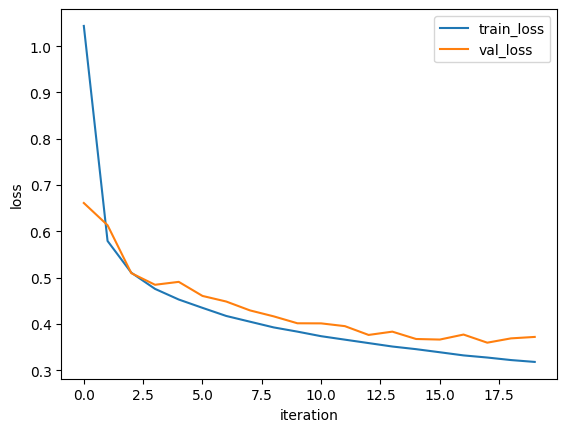

In [77]:
import matplotlib.pyplot as plt
plt.plot(cn_tf.losses)
plt.plot(cn_tf.val_losses)
plt.ylabel('loss')
plt.xlabel('iteration')
plt.legend(['train_loss', 'val_loss'])
plt.show()

In [78]:
cn_tf.score(x_val, y_val_encoded)

np.float64(0.8676666666666667)

In [79]:
# torch input
x_train_t = torch.tensor(x_train).reshape(-1, 1, 28, 28)
x_val_t = torch.tensor(x_val).reshape(-1, 1, 28, 28)
print(x_train_t.shape)

torch.Size([48000, 1, 28, 28])


In [80]:
cn_torch = ConvolutionNetwork_torch(n_kernels=10, units=100, batch_size=128, learning_rate=0.01)
cn_torch.fit(x_train_t, y_train_encoded, x_val=x_val_t, y_val=y_val_encoded, epochs=20)

에포크 0 .

C:\Users\USER\AppData\Local\Temp\ipykernel_14140\2550917535.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)


......................................................................................................................................................................................................................................................................................................................................................................................
에포크 1 .......................................................................................................................................................................................................................................................................................................................................................................................
에포크 2 .............................................................................................................................................................................................................................................

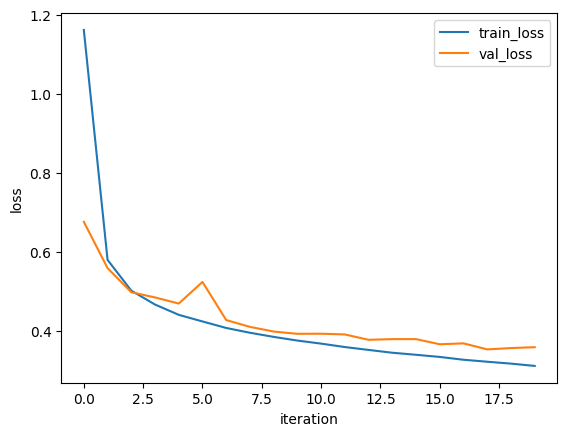

In [81]:
import matplotlib.pyplot as plt
plt.plot(cn_torch.losses)
plt.plot(cn_torch.val_losses)
plt.ylabel('loss')
plt.xlabel('iteration')
plt.legend(['train_loss', 'val_loss'])
plt.show()

In [82]:
cn_torch.score(x_val_t, y_val_encoded)

C:\Users\USER\AppData\Local\Temp\ipykernel_14140\2550917535.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)


np.float64(0.8741666666666666)

In [83]:
x_test_t = torch.tensor(x_test / 255.0).float().reshape(-1, 1, 28, 28)
y_test_encoded = tf.keras.utils.to_categorical(y_test)
cn_torch.score(x_test_t, y_test_encoded)

C:\Users\USER\AppData\Local\Temp\ipykernel_14140\2550917535.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)


np.float64(0.8626)

In [84]:
# 8-5 케라스로 합성곱 신경망을 만든다
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 첫번째 매개변수는 합성곱 커널의 개수
# 두번째 매개변수는 합성곱 커널의 (높이, 너비)
# input은 MNIST 이미지와 높이와 너비
conv1 = tf.keras.Sequential()
conv1.add(Conv2D(10, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)))

# 풀링층 추가
conv1.add(MaxPooling2D((2, 2)))

# 완전 연결층에 연결하기 위해 배치 차원을 제외하고 일렬로 펼쳐야 하는것
conv1.add(Flatten())

# 완전 연결층 쌓기
conv1.add(Dense(100, activation='relu'))
conv1.add(Dense(10, activation='softmax'))

# 모델 구조 살피기
conv1.summary()


c:\Users\USER\Desktop\AI\Do_it\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1960)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │       196,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,210 (770.35 KB)

 Trainable params: 197,210 (770.35 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
conv1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'f1_score'])

In [86]:
history = conv1.fit(x_train, y_train_encoded, epochs=20, validation_data=(x_val, y_val_encoded))

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8401 - f1_score: 0.8388 - loss: 0.4546 - val_accuracy: 0.8667 - val_f1_score: 0.8666 - val_loss: 0.3718
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8864 - f1_score: 0.8860 - loss: 0.3162 - val_accuracy: 0.8945 - val_f1_score: 0.8933 - val_loss: 0.2961
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9011 - f1_score: 0.9008 - loss: 0.2708 - val_accuracy: 0.9013 - val_f1_score: 0.9008 - val_loss: 0.2749
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9131 - f1_score: 0.9128 - loss: 0.2389 - val_accuracy: 0.9041 - val_f1_score: 0.9031 - val_loss: 0.2680
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9217 - f1_score: 0.9214 - loss: 0.2112 - val_accuracy: 0.9115 - val_f1_score: 0.9112 - val_loss: 0.2545
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9314 - f1_score: 0.9312 - loss: 0.1895 - val_accuracy: 0.9108 - val_f1_s

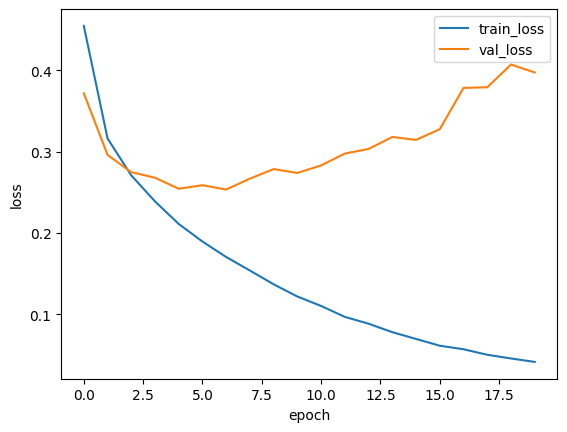

In [87]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'])
plt.show()

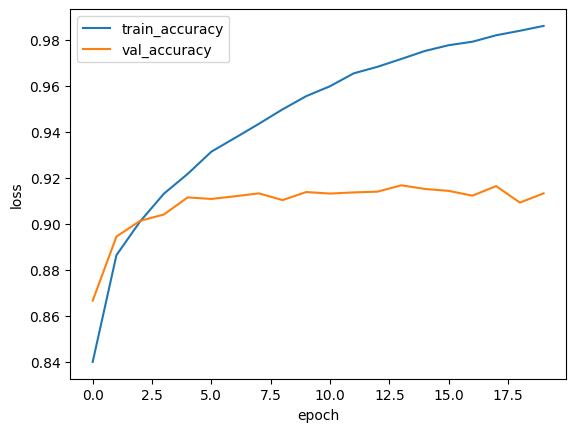

In [88]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_accuracy', 'val_accuracy'])
plt.show()

In [89]:
# 과대적합 해결 = drop out
# 테스트와 실전의 출력값을 드롭아웃 비율만큼 낮춰야 함
# Deep learning에서는 반대로 해결
# 훈련때 드롭아웃 비율만큼 뉴런의 출력을 높여 훈련

# Applying dropout
from tensorflow.keras.layers import Dropout
conv2 = tf.keras.Sequential()
conv2.add(Conv2D(10, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)))
conv2.add(MaxPooling2D((2, 2)))
conv2.add(Flatten())
conv2.add(Dropout(0.5))
conv2.add(Dense(100, activation='relu'))
conv2.add(Dense(10, activation='softmax'))
conv2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1960)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1960)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       196,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,210 (770.35 KB)

 Trainable params: 197,210 (770.35 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
conv2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'f1_score'])
history = conv2.fit(x_train, y_train_encoded, epochs=20, validation_data=(x_val, y_val_encoded))

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8158 - f1_score: 0.8145 - loss: 0.5098 - val_accuracy: 0.8792 - val_f1_score: 0.8775 - val_loss: 0.3491
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8635 - f1_score: 0.8626 - loss: 0.3766 - val_accuracy: 0.8889 - val_f1_score: 0.8892 - val_loss: 0.3125
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8763 - f1_score: 0.8756 - loss: 0.3372 - val_accuracy: 0.8937 - val_f1_score: 0.8935 - val_loss: 0.2892
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8861 - f1_score: 0.8856 - loss: 0.3125 - val_accuracy: 0.8999 - val_f1_score: 0.8994 - val_loss: 0.2728
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8920 - f1_score: 0.8915 - loss: 0.2941 - val_accuracy: 0.9059 - val_f1_score: 0.9066 - val_loss: 0.2638
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8973 - f1_score: 0.8969 - loss: 0.2755 - val_accuracy: 0.9070 - val_f1_s

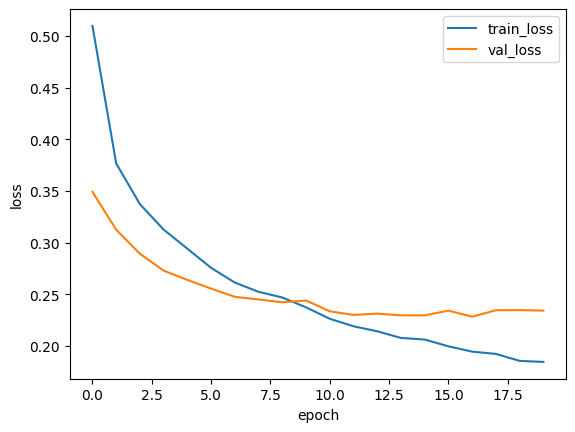

In [91]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'])
plt.show()

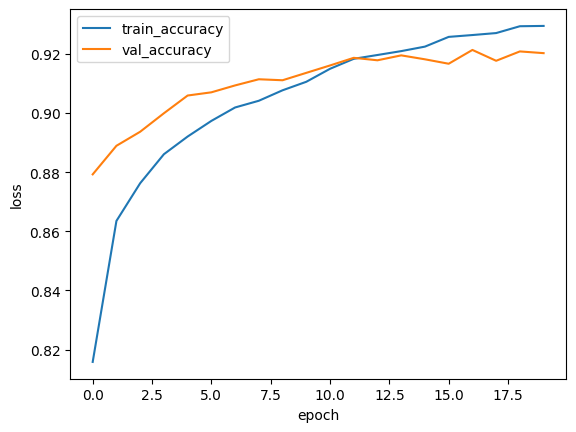

In [92]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_accuracy', 'val_accuracy'])
plt.show()

In [93]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# nn.Sequential in PyTorch = tf.keras.Sequential
# Difference: Keras merges the layer and its activation into one cell
#   e.g. Conv2D(10, (3,3), activation='relu')
# PyTorch separates them — the layer outputs values, then a separate ReLU applies
conv1_pt = nn.Sequential(
	nn.Conv2d(in_channels=1, out_channels=10, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Flatten(),
    nn.Linear(10 * 14 * 14, 100),	# Dense(100) -> nn.Linear(in_features, out_features)
    nn.ReLU(),
    nn.Linear(100, 10)				# Dense(10) - no softmax here!
									# CrossEntopyLoss applies softmax internally, same as Keras
)

# method 1
print(conv1_pt)

# method 2
from torchinfo import summary
summary(conv1_pt, input_size=(1, 1, 28, 28))
# input_size = (batch_size, channels, height, width)

Sequential(
  (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=1960, out_features=100, bias=True)
  (5): ReLU()
  (6): Linear(in_features=100, out_features=10, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 10, 28, 28]           100
├─ReLU: 1-2                              [1, 10, 28, 28]           --
├─MaxPool2d: 1-3                         [1, 10, 14, 14]           --
├─Flatten: 1-4                           [1, 1960]                 --
├─Linear: 1-5                            [1, 100]                  196,100
├─ReLU: 1-6                              [1, 100]                  --
├─Linear: 1-7                            [1, 10]                   1,010
Total params: 197,210
Trainable params: 197,210
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.28
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.79
Estimated Total Size (MB): 0.86

In [94]:
# Keras: conv1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# PyTorch has no .compile() — you just create the optimizer and loss function separately
from tqdm.notebook import tqdm
from sklearn.metrics import f1_score

optimizer1 = torch.optim.Adam(conv1_pt.parameters())
criterion = nn.CrossEntropyLoss()		# categorical_crossentropy -> CrossEntropyLoss

# Keras: history = conv1.fit(x_train, y_train_encoded, epochs=20, validation_data=(...))
# PyTorch: write the loop manually — same pattern as chapter 7
x_tr = x_train_t.float()
y_tr = torch.tensor(y_train_encoded).float()
x_v = x_val_t.float()
y_v = torch.tensor(y_val_encoded).float()

train_loader = DataLoader(TensorDataset(x_tr, y_tr), batch_size=32, shuffle=True)
history1 = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': [], 'val_f1': []}

epoch_bar = tqdm(range(20), desc='Training')	# outer bar

for epoch in epoch_bar:
    conv1_pt.train()	# tell the model is in training mode
    total_loss, correct, total = 0.0, 0, 0
    
    batch_bar = tqdm(train_loader, desc=f'Epoch {epoch+1:2d}')		# inner bar
    for x_batch, y_batch in batch_bar:
        optimizer1.zero_grad()
        logits = conv1_pt(x_batch)
        loss = criterion(logits, y_batch.argmax(dim=1))	# convert one-hot to index for CrossEntropyLoss
        loss.backward()
        optimizer1.step()
        
        total_loss += loss.item() * len(x_batch)
        correct += (logits.argmax(dim=1) == y_batch.argmax(dim=1)).sum().item()
        total += len(x_batch)
        
        batch_bar.set_postfix(loss=f'{loss.item():.4f}')  # live batch loss in the bar
        
    # validation
    conv1_pt.eval()
    with torch.no_grad():
        val_logits = conv1_pt(x_v)
        val_loss = criterion(val_logits, y_v.argmax(dim=1)).item()
        val_preds = val_logits.argmax(dim=1).numpy()
        val_true = y_v.argmax(dim=1).numpy()
        val_acc = (val_logits.argmax(dim=1) == y_v.argmax(dim=1)).float().mean().item()
        val_f1 = f1_score(val_true, val_preds, average='macro')
        # average='macro': computes f1 per class then takes unweighted mean
        # matches what Keras reports as f1_score by default
        
    history1['loss'].append(total_loss / total)
    history1['val_loss'].append(val_loss)
    history1['accuracy'].append(correct / total)
    history1['val_accuracy'].append(val_acc)
    history1['val_f1'].append(val_f1)
    
    # update the outer epoch bar with final metrics for that epoch
    epoch_bar.set_postfix(
        loss    = f'{history1["loss"][-1]:.4f}',
        val_loss= f'{val_loss:.4f}',
        val_acc = f'{val_acc:.4f}',
        val_f1  = f'{val_f1:.4f}'
    )

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch  1:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch  2:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch  3:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch  4:   0%|          | 0/1500 [00:00<?, ?it/s]

...

Epoch 16:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 17:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 18:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 19:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 20:   0%|          | 0/1500 [00:00<?, ?it/s]

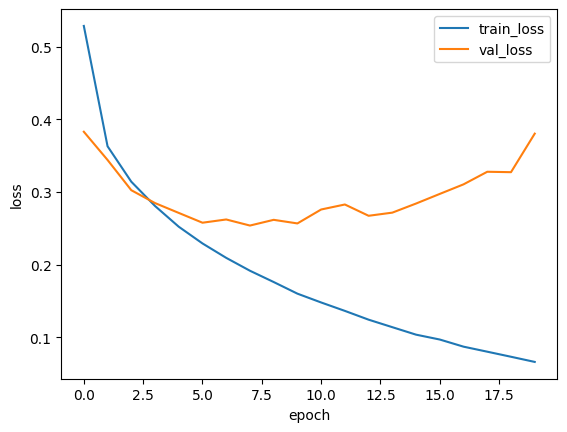

In [95]:
plt.plot(history1['loss'])
plt.plot(history1['val_loss'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'])
plt.show()

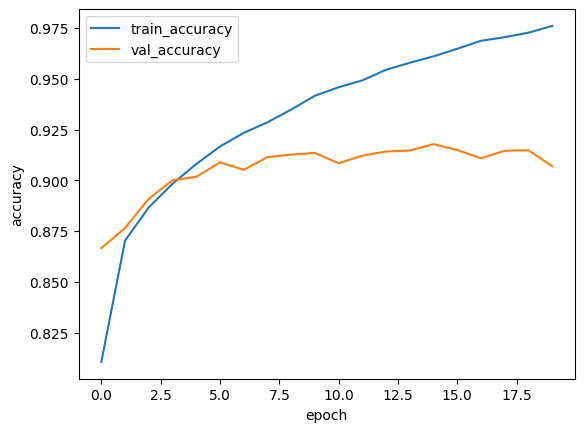

In [96]:
plt.plot(history1['accuracy'])
plt.plot(history1['val_accuracy'])
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train_accuracy', 'val_accuracy'])
plt.show()

In [97]:
# Keras: conv2.add(Dropout(0.5)) inserted after Flatten, before Dense(100)
# PyTorch: nn.Dropout(0.5) — placed exactly the same position in the Sequential

conv2_pt = nn.Sequential(
    nn.Conv2d(1, 10, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Flatten(),
    nn.Dropout(0.5),          # KEY DIFFERENCE: .train() mode drops neurons randomly
                               # .eval() mode disables dropout — this is why model.train()
                               # and model.eval() matter; Keras handles this automatically
    nn.Linear(10 * 14 * 14, 100),
    nn.ReLU(),
    nn.Linear(100, 10),
)

# method 1
# print(conv2_pt)

# method 2
summary(conv2_pt, input_size=(1, 1, 28, 28))
# input_size = (batch_size, channels, height, width)

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 10, 28, 28]           100
├─ReLU: 1-2                              [1, 10, 28, 28]           --
├─MaxPool2d: 1-3                         [1, 10, 14, 14]           --
├─Flatten: 1-4                           [1, 1960]                 --
├─Dropout: 1-5                           [1, 1960]                 --
├─Linear: 1-6                            [1, 100]                  196,100
├─ReLU: 1-7                              [1, 100]                  --
├─Linear: 1-8                            [1, 10]                   1,010
Total params: 197,210
Trainable params: 197,210
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.28
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.79
Estimated Total Size (MB): 0.86

In [98]:
# Keras: conv1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# PyTorch has no .compile() — you just create the optimizer and loss function separately

optimizer2 = torch.optim.Adam(conv2_pt.parameters())
criterion = nn.CrossEntropyLoss()		# categorical_crossentropy -> CrossEntropyLoss

# Keras: history = conv1.fit(x_train, y_train_encoded, epochs=20, validation_data=(...))
# PyTorch: write the loop manually — same pattern as chapter 7
x_tr = x_train_t.float()
y_tr = torch.tensor(y_train_encoded).float()
x_v = x_val_t.float()
y_v = torch.tensor(y_val_encoded).float()

train_loader = DataLoader(TensorDataset(x_tr, y_tr), batch_size=32, shuffle=True)
history2 = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': [], 'val_f1': []}

epoch_bar = tqdm(range(20), desc='Training')	# outer bar

for epoch in epoch_bar:
    conv2_pt.train()	# tell the model is in training mode
    total_loss, correct, total = 0.0, 0, 0
    
    batch_bar = tqdm(train_loader, desc=f'Epoch {epoch+1:2d}')		# inner bar
    for x_batch, y_batch in batch_bar:
        optimizer2.zero_grad()
        logits = conv2_pt(x_batch)
        loss = criterion(logits, y_batch.argmax(dim=1))	# convert one-hot to index for CrossEntropyLoss
        loss.backward()
        optimizer2.step()
        
        total_loss += loss.item() * len(x_batch)
        correct += (logits.argmax(dim=1) == y_batch.argmax(dim=1)).sum().item()
        total += len(x_batch)
        
        batch_bar.set_postfix(loss=f'{loss.item():.4f}')  # live batch loss in the bar
        
    # validation
    conv2_pt.eval()
    with torch.no_grad():
        val_logits = conv2_pt(x_v)
        val_loss = criterion(val_logits, y_v.argmax(dim=1)).item()
        val_preds = val_logits.argmax(dim=1).numpy()
        val_true = y_v.argmax(dim=1).numpy()
        val_acc = (val_logits.argmax(dim=1) == y_v.argmax(dim=1)).float().mean().item()
        val_f1 = f1_score(val_true, val_preds, average='macro')
        # average='macro': computes f1 per class then takes unweighted mean
        # matches what Keras reports as f1_score by default
        
    history2['loss'].append(total_loss / total)
    history2['val_loss'].append(val_loss)
    history2['accuracy'].append(correct / total)
    history2['val_accuracy'].append(val_acc)
    history2['val_f1'].append(val_f1)
    
    # update the outer epoch bar with final metrics for that epoch
    epoch_bar.set_postfix(
        loss    = f'{history2["loss"][-1]:.4f}',
        val_loss= f'{val_loss:.4f}',
        val_acc = f'{val_acc:.4f}',
        val_f1  = f'{val_f1:.4f}'
    )

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch  1:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch  2:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch  3:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch  4:   0%|          | 0/1500 [00:00<?, ?it/s]

...

Epoch 16:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 17:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 18:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 19:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 20:   0%|          | 0/1500 [00:00<?, ?it/s]

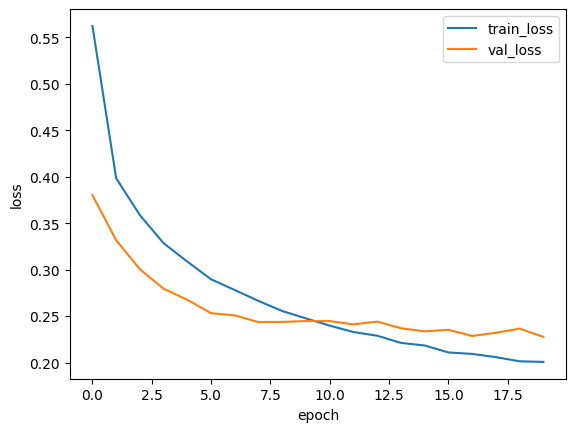

In [99]:
plt.plot(history2['loss'])
plt.plot(history2['val_loss'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'])
plt.show()

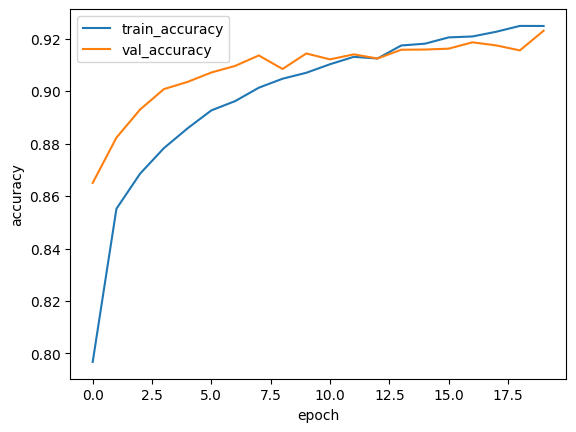

In [100]:
plt.plot(history2['accuracy'])
plt.plot(history2['val_accuracy'])
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train_accuracy', 'val_accuracy'])
plt.show()